In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from CoupledModel import CoupledModel
from diagnostics import plot_distribution, plot_power_spectrum

In [3]:


AMOC_load = {
    **torch.load('amoc_model.pth', weights_only=False),
    'scaler': 'scalers_AMOC.pkl'
}
SFWF_load = {
    **torch.load('SFWF_model.pth', weights_only=False),
    'scaler': 'scalers_SFWF.pkl'
}
PD_200m_load = {
    **torch.load('PD_200m_model.pth', weights_only=False),
    'scaler': 'scalers_PD_200m.pkl'
}

model = CoupledModel(AMOC_load, SFWF_load, PD_200m_load)

X = pd.read_csv('../data/CESMDataset_Try.csv')
device = 'cpu'
start_idx_off = 5100
start_idx_on = 6600
lag = 100
horizon = 65
rho = 0.0
k = 0.3

AMOC_features = ['SFWF', 'PD_200m']
SFWF_features = ['AMOC', 'PD_200m']
PD_200m_features = ['SFWF', 'AMOC']

steps = 9000

from scipy.stats import norm

threshold = 13

on = X['AMOC'] > threshold
off = X['AMOC'] < threshold
AMOC_on = X[on]['AMOC']
AMOC_off = X[off]['AMOC']
SFWF_on = X[on]['SFWF']
SFWF_off = X[off]['SFWF']
PD_200m_on = X[on]['PD_200m']
PD_200m_off = X[off]['PD_200m']

data_on  = np.column_stack([AMOC_on, SFWF_on, PD_200m_on])
data_off = np.column_stack([AMOC_off, SFWF_off, PD_200m_off])

cov_on    = np.cov(data_on.T)      
cov_off   = np.cov(data_off.T)

#AMOC_on, SFWF_on, PD_200m_on = model.predict(device, X, start_idx_on, lag, horizon, AMOC_features, SFWF_features, PD_200m_features, steps, threshold, cov_on, cov_off, rho, k)
#AMOC_off, SFWF_off, PD_200m_off = model.predict(device, X, start_idx_off, lag, horizon, AMOC_features, SFWF_features, PD_200m_features, steps, threshold, cov_on, cov_off, rho, k)



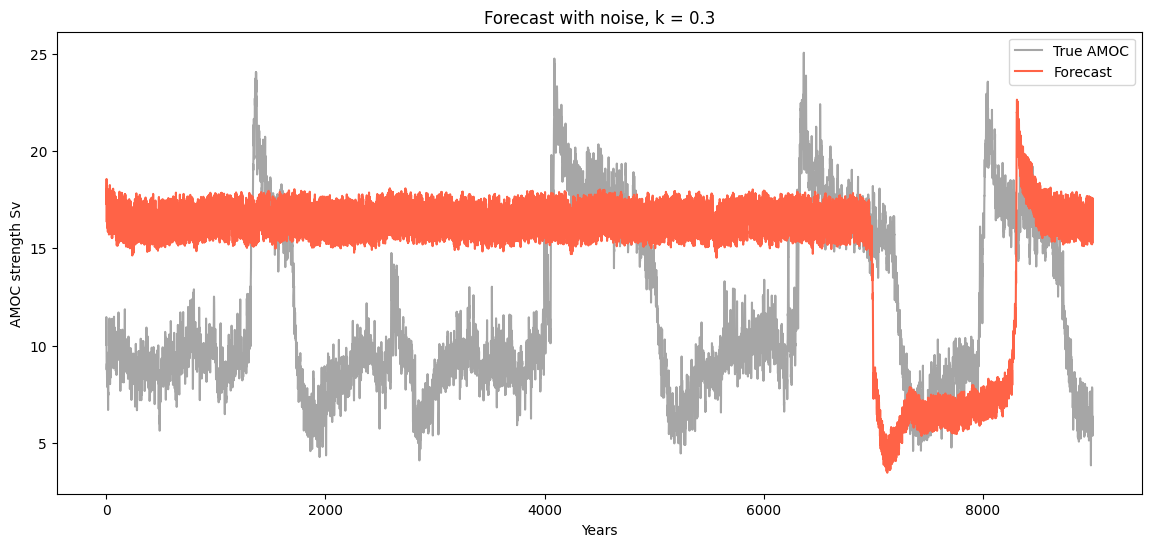

In [104]:

plt.figure(figsize=(14,6))

x = np.arange(steps+1)

plt.plot(x, X['AMOC'][start_idx_off:start_idx_off+steps+1], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, AMOC_on, label = 'Forecast', color = '#FF6347')
plt.title('Forecast with noise, k = 0.3')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.savefig('Coupled_V1_noise.png')
plt.legend()

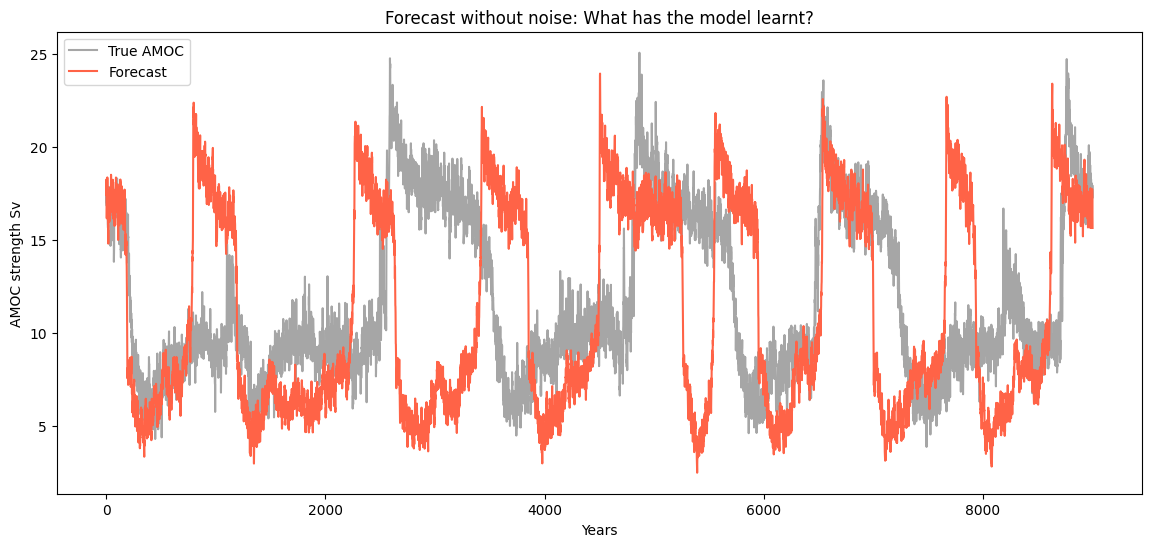

In [88]:
plt.figure(figsize=(14,6))

x = np.arange(steps+1)

plt.plot(x, X['AMOC'][start_idx_on:start_idx_on+steps+1], label = 'True AMOC', color = 'grey', alpha = 0.7)
plt.plot(x, AMOC_on, label = 'Forecast', color = '#FF6347')
plt.title('Forecast without noise: What has the model learnt?')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
plt.savefig('Coupled_V1_noise_rho.png')
plt.legend()

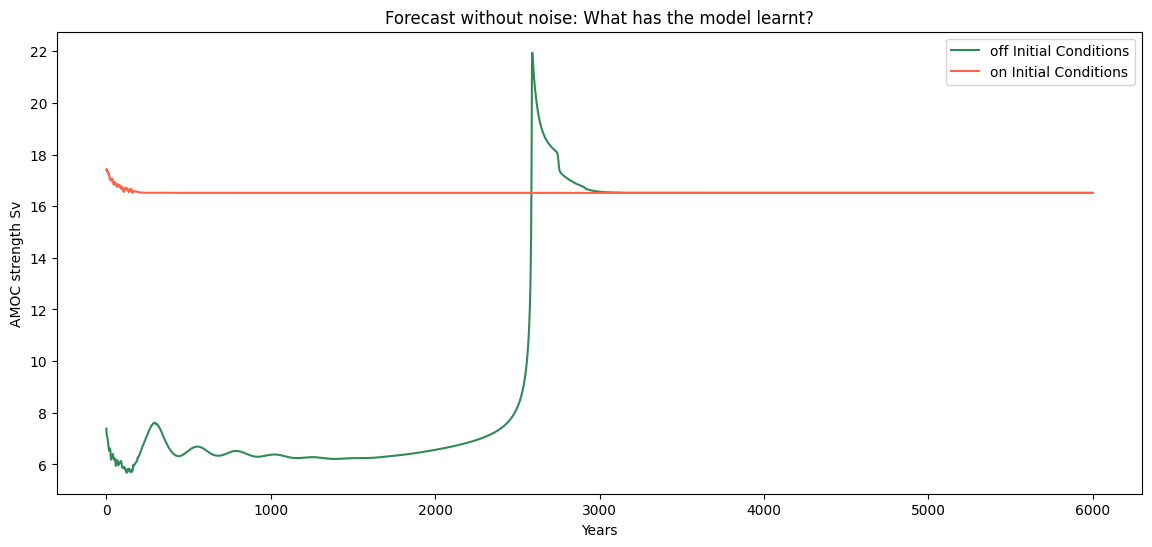

In [ ]:
plt.figure(figsize=(14,6))

x = np.arange(steps+1)

plt.plot(x, AMOC_off, label = 'off Initial Conditions', color = '#2E8B57')
plt.plot(x, AMOC_on, label = 'on Initial Conditions', color = '#FF6347')
plt.title('Forecast without noise: What has the model learnt?')
plt.xlabel('Years')
plt.ylabel('AMOC strength Sv')
#plt.savefig('Coupled_V1_off_on_no_noise.png')
plt.legend()

In [4]:
AMOC_data = pd.read_csv('/Users/isakrockstrom/Desktop/Ocean/AML_proj/data/CombinedDatasetLongUnsmooth.csv')
k = 0.3
rho = 0.5
steps = len(AMOC_data)
AMOC_full, SFWF_full, PD_200m_full = model.predict(device, X, start_idx_on, lag, horizon, AMOC_features, SFWF_features, PD_200m_features, steps, threshold, cov_on, cov_off, rho, k)

/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/Users/isakrockstrom/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


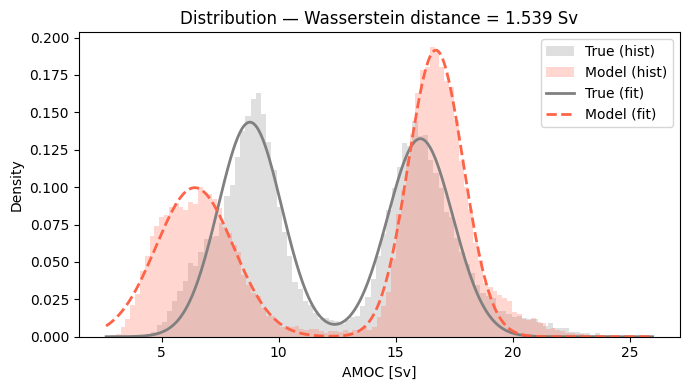

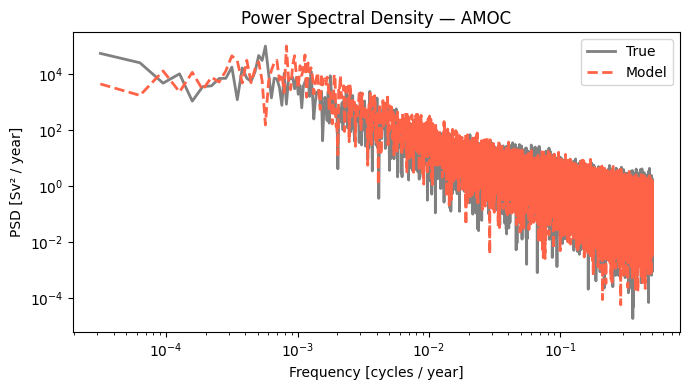

In [5]:
data_color = 'gray'
pred_color = '#FF6347'

plot_distribution(AMOC_data['AMOC_40N'], AMOC_full, var_name='AMOC', true_color = data_color, pred_color=pred_color)
plot_power_spectrum(AMOC_data['AMOC_40N'], AMOC_full, var_name='AMOC', true_color = data_color, pred_color=pred_color)